# dtype experiment & version bisect

This notebook answers two follow-up questions after identifying `matrix.cholesky`
as the regressed stage:

1. **Is the regression dtype-specific?** (float32 vs float64)
2. **Which JAX version first introduced it?** (binary bisect between 0.4.31 and 0.9.1)

## Float32 vs Float64: is the regression dtype-specific?

The `matrix.cholesky` scan operates on f64 arrays (JAX x64 is forced on by the
benchmark harness).  

XLA's CPU back-end generates separate code paths for f32
and f64 — if the regression only appears in f64, that strongly localizes the
XLA bug to double-precision codegen.

Run the experiment once per JAX version from the project root:

```bash
# baseline
uv sync --extra jax0431
uv run python -m benchmarks.dtype_check --output results/dtype-check/jax0431.json

# candidate
uv sync --extra jax091
uv run python -m benchmarks.dtype_check --output results/dtype-check/jax091.json
```

The `dtype_check` script:
- **enables x64** globally 
- builds **two independent QSMs** (Quasi-Separable Matrices)
  - one cast to f32
  - one cast to f64  
- **compiles and times** each separately 
  - (so the two dtypes are never compared in the same JIT trace)

The cell below loads both JSON files and plots median `matrix.cholesky` latency
for f32 and f64 side by side, for each JAX version.

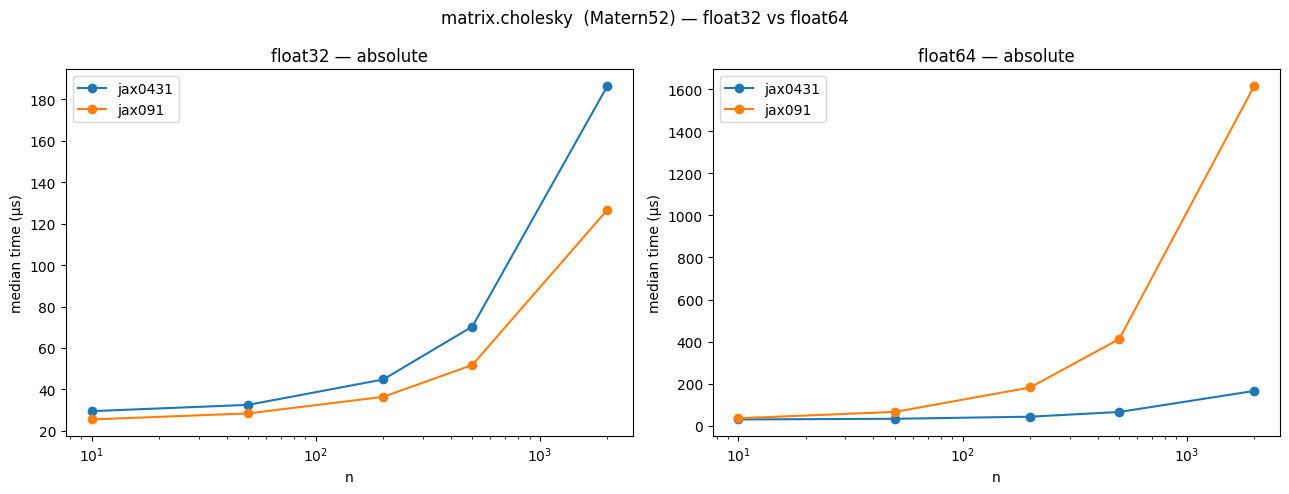

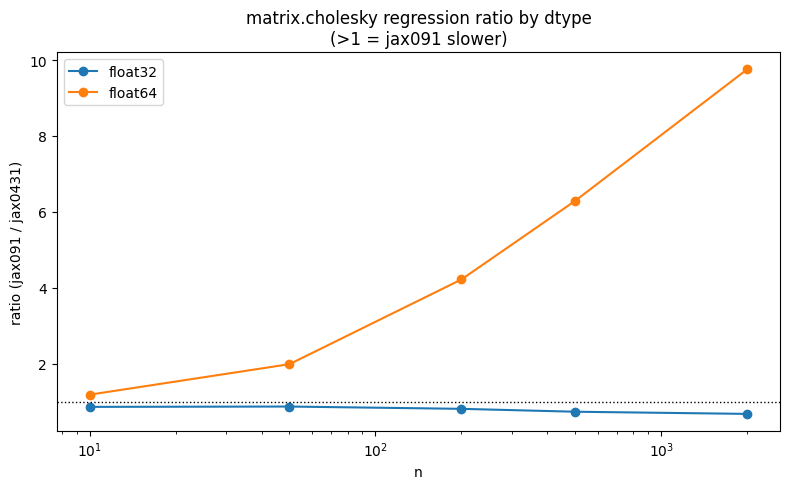

ratio (jax091 / jax0431),float32,float64
n,,
10,0.86,1.19
50,0.87,1.99
200,0.81,4.22
500,0.74,6.29
2000,0.68,9.76


In [1]:
from pathlib import Path
import json, pandas as pd, matplotlib.pyplot as plt, numpy as np

try:
    project_root = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    project_root = Path().resolve().parent  # fallback for standard Jupyter

results_dir = project_root / "results" / "dtype-check"
dtype_files = {
    "jax0431": results_dir / "jax0431.json",
    "jax091":  results_dir / "jax091.json",
}

missing = [k for k, p in dtype_files.items() if not p.exists()]
if missing:
    print(f"Missing dtype-check files for: {missing}")
    print("Run the dtype_check commands above, then re-run this cell.")
else:
    frames = []
    for version, path in dtype_files.items():
        payload = json.loads(path.read_text())
        df_d = pd.DataFrame(payload["results"])
        df_d["version"] = version
        df_d["jax"] = payload["jax"]
        frames.append(df_d)

    dc = pd.concat(frames, ignore_index=True)
    dc["median_us"] = dc["median_s"] * 1e6

    dtypes = ["float32", "float64"]
    versions = list(dtype_files.keys())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    for col, dtype in enumerate(dtypes):
        ax = axes[col]
        for version in versions:
            sub = dc[(dc["dtype"] == dtype) & (dc["version"] == version)].sort_values("n")
            ax.plot(sub["n"], sub["median_us"], "o-", label=version)
        ax.set_title(f"{dtype} — absolute")
        ax.set_xlabel("n")
        ax.set_ylabel("median time (μs)")
        ax.set_xscale("log")
        ax.legend()
    fig.suptitle("matrix.cholesky  (Matern52) — float32 vs float64", fontsize=12)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    base = dc[dc["version"] == "jax0431"].set_index(["dtype", "n"])["median_s"]
    cand = dc[dc["version"] == "jax091"].set_index(["dtype", "n"])["median_s"]
    ratio = (cand / base).reset_index()
    ratio.columns = ["dtype", "n", "ratio"]

    for dtype, grp in ratio.groupby("dtype"):
        grp = grp.sort_values("n")
        ax.plot(grp["n"], grp["ratio"], "o-", label=dtype)
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1)
    ax.set_xlabel("n")
    ax.set_ylabel("ratio (jax091 / jax0431)")
    ax.set_title("matrix.cholesky regression ratio by dtype\n(>1 = jax091 slower)")
    ax.set_xscale("log")
    ax.legend()
    plt.tight_layout()
    plt.show()

    tbl = ratio.pivot(index="n", columns="dtype", values="ratio").round(2)
    tbl.columns.name = "ratio  (jax091 / jax0431)"
    display(tbl)

## Version bisect: which JAX release introduced the regression?

We know the regression is present in 0.4.33 and absent in 0.4.31. To file a
useful bug report we want to identify the first bad version — or at least
bracket it to a narrow range.

A reasonable bisect ladder (roughly binary search over the ~18-month gap):

| Step | Version | Expected |
|---|---|---|
| 0 | 0.4.31 | baseline (fast) |
| 1 | 0.6.0 | midpoint — fast or slow? |
| 2a | 0.5.0 | if 0.6 is slow: is 0.5 also slow? |
| 2b | 0.7.0 | if 0.6 is fast: is 0.7 slow? |
| 3 | narrow further based on above | — |

For each candidate version, add it to `pyproject.toml` as a new extra and run:

```bash
uv sync --extra jax<version>
uv run python -m benchmarks.repro --output results/bisect/jax<version>-repro.json
```

Then re-run the cell below, which loads all repro JSONs found in `results/bisect/`
and plots the `lax.scan` median at n=2000 as a function of JAX version.

In [ ]:
# Generate shell commands to copy/paste:

for jax_version in ["0431", "0433", "0435", "050", "060", "070", "080", "091"]:
    print(f"# JAX {jax_version}")
    extra_name = f"jax{jax_version}"
    output_name = f"results/bisect/{extra_name}-repro.json"
    print(f"uv sync --extra {extra_name}")
    print(f"uv run python -m benchmarks.repro --output {output_name}")
    print()

### Notes
- jax 0.4.32 was pulled from PyPI
- `benchmarks.repro` has no tinygp/equinox dependency, so it works across all JAX versions in the bisect range

### Compare versions

,JAX version,median (μs),ratio vs earliest
0,0.4.31,103.02,1.00
1,0.4.33,1087.81,10.56
2,0.4.35,1051.54,10.21
3,0.5.0,1181.58,11.47
4,0.6.0,1100.42,10.68
5,0.7.0,1065.17,10.34
6,0.8.0,1078.75,10.47
7,0.9.1,1127.50,10.94


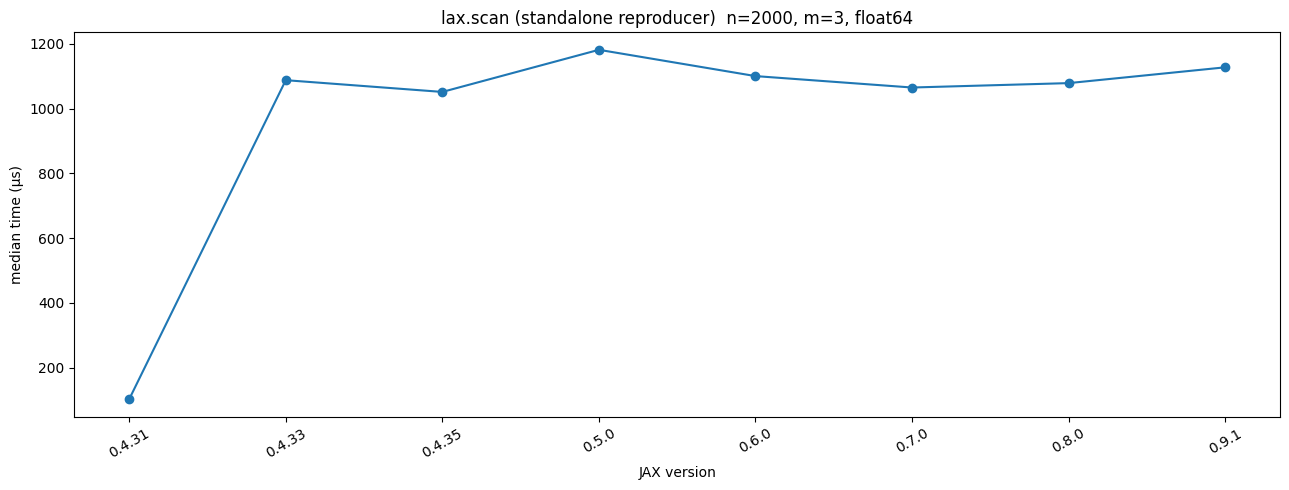

In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    project_root = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    project_root = Path().resolve().parent  # fallback for standard Jupyter

results_dir = project_root / "results" / "bisect"

records = []
for path in sorted(results_dir.glob("*-repro.json")):
    records.append(json.loads(path.read_text()))

if not records:
    print("No repro JSON files found. Run the commands above first.")
else:
    sub = (
        pd.DataFrame(records)
        .drop_duplicates(subset=["jax"])
        .sort_values("jax")
        .copy()
    )
    sub["median_us"] = sub["median_s"] * 1e6
    sub["ratio"] = sub["median_us"] / sub["median_us"].iloc[0]

    display(sub[["jax", "median_us", "ratio"]].rename(
        columns={"jax": "JAX version", "median_us": "median (μs)", "ratio": "ratio vs earliest"}
    ).reset_index(drop=True).style.format({"median (μs)": "{:.2f}", "ratio vs earliest": "{:.2f}"}))

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(sub["jax"], sub["median_us"], "o-")
    ax.set_xlabel("JAX version")
    ax.set_ylabel("median time (μs)")
    ax.set_title(f"lax.scan (standalone reproducer)  n={sub['n'].iloc[0]}, m={sub['m'].iloc[0]}, {sub['dtype'].iloc[0]}")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()